In [1]:
#Importing necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.future.infer_string = True

In [4]:
df = pd.read_excel("bikes.xlsx", sheet_name = "Transactions")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    20050 non-null  int64         
 1   Transaction Date  20050 non-null  datetime64[ns]
 2   ONLine OrdeR      19689 non-null  float64       
 3   Order Status      20050 non-null  str           
 4   BRAND             19853 non-null  str           
 5   Product LINE      19853 non-null  str           
 6   PRODUCT CLAss     19853 non-null  str           
 7   product_size      19853 non-null  str           
 8   selling price     20050 non-null  object        
 9   StanDARD COST     19853 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1), str(5)
memory usage: 2.2+ MB


#### Data Exploration

In [6]:
df.head()

,Transaction ID,Transaction Date,ONLine OrdeR,Order Status,BRAND,Product LINE,PRODUCT CLAss,product_size,selling price,StanDARD COST
0,1,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62
1,2,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47USD,388.92
2,3,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82
3,4,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10
4,5,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.3,709.48


In [7]:
df.columns

Index(['Transaction ID', 'Transaction Date', 'ONLine OrdeR', 'Order Status',
       'BRAND', 'Product LINE', 'PRODUCT CLAss', 'product_size',
       'selling price', 'StanDARD COST'],
      dtype='str')

In [8]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['transaction_id', 'transaction_date', 'online_order', 'order_status',
       'brand', 'product_line', 'product_class', 'product_size',
       'selling_price', 'standard_cost'],
      dtype='str')

In [9]:
df.head()

,transaction_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,selling_price,standard_cost
0,1,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62
1,2,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47USD,388.92
2,3,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82
3,4,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10
4,5,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.3,709.48


In [10]:
df.duplicated().sum()

np.int64(49)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
#checking for missing values

df.isnull().sum()

transaction_id        0
transaction_date      0
online_order        360
order_status          0
brand               197
product_line        197
product_class       197
product_size        197
selling_price         0
standard_cost       197
dtype: int64

In [13]:
bikes = df.copy()

#### Data Cleaning

In [14]:
bikes['transaction_id'].nunique()

20000

In [15]:
bikes.shape

(20001, 10)

This means there's a duplicate transaction

In [16]:
#Renaming the online order column
bikes.rename(columns = {'online_order': 'sales_channel'}, inplace=True)

In [17]:
#replacing 1s with Online and 0s with In-store
bikes['sales_channel'] = bikes['sales_channel'].map({1: "Online", 0:"In-Store"})

In [18]:
bikes.head()

,transaction_id,transaction_date,sales_channel,order_status,brand,product_line,product_class,product_size,selling_price,standard_cost
0,1,2017-02-25,In-Store,Approved,Solex,Standard,medium,medium,71.49,53.62
1,2,2017-05-21,Online,Approved,Trek Bicycles,Standard,medium,large,2091.47USD,388.92
2,3,2017-10-16,In-Store,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82
3,4,2017-08-31,In-Store,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10
4,5,2017-10-01,Online,Approved,Giant Bicycles,Standard,medium,large,1765.3,709.48


In [19]:
bikes["order_status"].unique()

<ArrowStringArrayNumpySemantics>
['Approved', 'Cancelled']
Length: 2, dtype: str

In [20]:
#removing rows with cancelled in order status because it shouldn't be part of transaction

app_bikes = bikes[bikes['order_status'] == "Approved"].copy()

In [21]:
#since we all have our dataset to be approved alone, then we don't need the order_status column. 
#dropping the order status column

app_bikes.drop(columns='order_status', inplace=True)

In [22]:
app_bikes.head()

,transaction_id,transaction_date,sales_channel,brand,product_line,product_class,product_size,selling_price,standard_cost
0,1,2017-02-25,In-Store,Solex,Standard,medium,medium,71.49,53.62
1,2,2017-05-21,Online,Trek Bicycles,Standard,medium,large,2091.47USD,388.92
2,3,2017-10-16,In-Store,OHM Cycles,Standard,low,medium,1793.43,248.82
3,4,2017-08-31,In-Store,Norco Bicycles,Standard,medium,medium,1198.46,381.10
4,5,2017-10-01,Online,Giant Bicycles,Standard,medium,large,1765.3,709.48


In [23]:
app_bikes['brand'].unique()

<ArrowStringArrayNumpySemantics>
[         'Solex',  'Trek Bicycles',     'OHM Cycles', 'Norco Bicycles',
 'Giant Bicycles',       'WeareA2B',              nan]
Length: 7, dtype: str

In [24]:
app_bikes['brand'].fillna("Unknown", inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_31708\392155752.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_bikes['brand'].fillna("Unknown", inplace=True)


In [25]:
app_bikes['brand'].unique()

<ArrowStringArrayNumpySemantics>
[         'Solex',  'Trek Bicycles',     'OHM Cycles', 'Norco Bicycles',
 'Giant Bicycles',       'WeareA2B',        'Unknown']
Length: 7, dtype: str

In [26]:
app_bikes['product_line'].unique()

<ArrowStringArrayNumpySemantics>
['Standard', 'Road', 'Mountain', 'Touring', nan]
Length: 5, dtype: str

In [27]:
app_bikes['product_line'].fillna("Unknown", inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_31708\690416991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_bikes['product_line'].fillna("Unknown", inplace=True)


In [28]:
app_bikes['product_line'].unique()

<ArrowStringArrayNumpySemantics>
['Standard', 'Road', 'Mountain', 'Touring', 'Unknown']
Length: 5, dtype: str

In [29]:
app_bikes['product_class'].unique()

<ArrowStringArrayNumpySemantics>
['medium', 'low', 'high', nan, 'LOW', 'High', 'Low', 'Medium']
Length: 8, dtype: str

In [30]:
app_bikes['product_class'] = app_bikes['product_class'].str.capitalize()

In [31]:
app_bikes['product_class']

0        Medium
1        Medium
2           Low
3        Medium
4        Medium
          ...  
20045      High
20046    Medium
20047    Medium
20048      High
20049    Medium
Name: product_class, Length: 19822, dtype: str

In [32]:
app_bikes['product_size'].unique()

<ArrowStringArrayNumpySemantics>
['medium', 'large', 'small', nan]
Length: 4, dtype: str

In [33]:
app_bikes['product_size'] = app_bikes['product_size'].str.capitalize()

In [34]:
app_bikes['product_size'].unique()

<ArrowStringArrayNumpySemantics>
['Medium', 'Large', 'Small', nan]
Length: 4, dtype: str

In [35]:
#SELLING PRICE
app_bikes['selling_price']

0             71.49
1        2091.47USD
2           1793.43
3           1198.46
4            1765.3
            ...    
20045       2005.66
20046        416.98
20047        1636.9
20048        227.88
20049       1775.81
Name: selling_price, Length: 19822, dtype: object

In [36]:
#removing all letters in the selling price colun and coverting the data type to numeric

app_bikes['selling_price'] = pd.to_numeric(app_bikes['selling_price'].replace("[a-zA-Z]", "", regex=True))

In [37]:
app_bikes['selling_price']

0          71.49
1        2091.47
2        1793.43
3        1198.46
4        1765.30
          ...   
20045    2005.66
20046     416.98
20047    1636.90
20048     227.88
20049    1775.81
Name: selling_price, Length: 19822, dtype: float64

In [38]:
cols = ["product_class", "product_size"]

for col in cols:
    app_bikes.fillna({col: 'Unknown'}, inplace = True)

In [39]:
app_bikes["product_class"].unique()

<ArrowStringArrayNumpySemantics>
['Medium', 'Low', 'High', 'Unknown']
Length: 4, dtype: str

In [40]:
app_bikes.duplicated().sum()

np.int64(1)

In [41]:
app_bikes.drop_duplicates(inplace=True)

In [42]:
app_bikes.isnull().sum()

transaction_id        0
transaction_date      0
sales_channel       354
brand                 0
product_line          0
product_class         0
product_size          0
selling_price         0
standard_cost       196
dtype: int64

In [43]:
# filter out Unknowns and Focus on the Knowns

app_bikes['brand'].value_counts()

brand
Solex             4211
Giant Bicycles    3283
WeareA2B          3265
OHM Cycles        3016
Trek Bicycles     2965
Norco Bicycles    2885
Unknown            196
Name: count, dtype: int64

In [44]:
new_bikes = app_bikes[app_bikes['brand'] != "Unknown"].copy()

In [45]:
new_bikes.isnull().sum()

transaction_id        0
transaction_date      0
sales_channel       352
brand                 0
product_line          0
product_class         0
product_size          0
selling_price         0
standard_cost         0
dtype: int64

In [46]:
#filter missing values

new_bikes = new_bikes[new_bikes['sales_channel'].notna()].copy()

In [47]:
new_bikes.isna().sum()

transaction_id      0
transaction_date    0
sales_channel       0
brand               0
product_line        0
product_class       0
product_size        0
selling_price       0
standard_cost       0
dtype: int64

In [48]:
new_bikes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19273 entries, 0 to 20049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    19273 non-null  int64         
 1   transaction_date  19273 non-null  datetime64[ns]
 2   sales_channel     19273 non-null  str           
 3   brand             19273 non-null  str           
 4   product_line      19273 non-null  str           
 5   product_class     19273 non-null  str           
 6   product_size      19273 non-null  str           
 7   selling_price     19273 non-null  float64       
 8   standard_cost     19273 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), str(5)
memory usage: 2.1 MB


#### *ANALYSIS*

#### **What brands of products should be focused on?**

In [49]:
purchase_by_brand = new_bikes['brand'].value_counts(ascending =True)
purchase_by_brand

brand
Norco Bicycles    2840
Trek Bicycles     2906
OHM Cycles        2967
WeareA2B          3215
Giant Bicycles    3217
Solex             4128
Name: count, dtype: int64

In [50]:
purchase_by_brand.index

Index(['Norco Bicycles', 'Trek Bicycles', 'OHM Cycles', 'WeareA2B',
       'Giant Bicycles', 'Solex'],
      dtype='str', name='brand')

In [51]:
purchase_by_brand.values

array([2840, 2906, 2967, 3215, 3217, 4128])

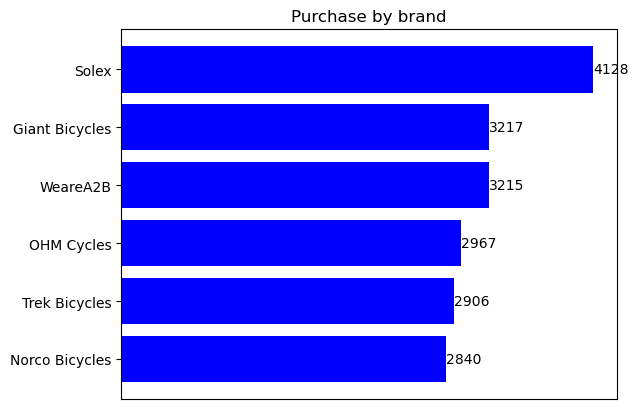

In [52]:
pb_bars = plt.barh(purchase_by_brand.index, purchase_by_brand.values, color = 'blue')
plt.title("Purchase by brand")
plt.xticks([])
plt.bar_label(pb_bars, purchase_by_brand.values)
plt.show()

Solex is the most purchased brand with 4,128 transactions, significantly ahead of Giant Bicycles and WeareA2B which are closely matched in second 
and third place respectively.

In [53]:
#creating profit column
new_bikes['profit'] = new_bikes['selling_price'] - new_bikes['standard_cost']

In [54]:
pd.options.display.float_format = "{:.2f}".format

In [55]:
profit_by_brand = new_bikes.groupby('brand')['profit'].sum().sort_values()
profit_by_brand

brand
Norco Bicycles    845329.79
OHM Cycles       1441779.79
Giant Bicycles   1528709.39
Trek Bicycles    1792193.09
Solex            2330943.46
WeareA2B         2693693.34
Name: profit, dtype: float64

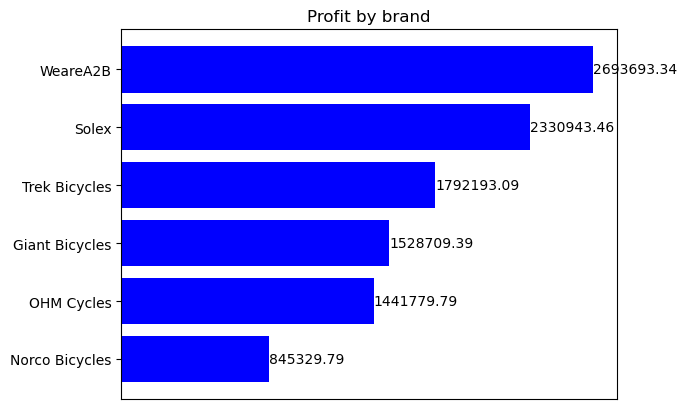

In [56]:
pb_bars = plt.barh(profit_by_brand.index, profit_by_brand.values, color = 'blue')
plt.title("Profit by brand")
plt.bar_label(pb_bars, profit_by_brand.values.round(2))
plt.xticks([]);

WeareA2B generates the highest profit despite ranking third in total purchases. 
This means WeareA2B bikes sell at a higher margin per transaction, making it 
the most financially valuable brand for Biker Nation even though Solex moves 
more units.

#### *What are the most profitable months? Is there a trend?*

In [57]:
new_bikes.columns

Index(['transaction_id', 'transaction_date', 'sales_channel', 'brand',
       'product_line', 'product_class', 'product_size', 'selling_price',
       'standard_cost', 'profit'],
      dtype='str')

In [60]:
#Extracting month from date

new_bikes['month'] = new_bikes['transaction_date'].dt.month
new_bikes['month']

0         2
1         5
2        10
3         8
4        10
         ..
20045     6
20046    11
20047     4
20048     7
20049     9
Name: month, Length: 19273, dtype: int32

In [62]:
profit_by_month = new_bikes.groupby('month')['profit'].sum()
profit_by_month

month
1    904893.87
2    851637.74
3    860463.96
4    879340.04
5    895150.25
6    831655.67
7    913216.65
8    944061.90
9    835514.83
10   959983.13
11   890574.74
12   866156.08
Name: profit, dtype: float64

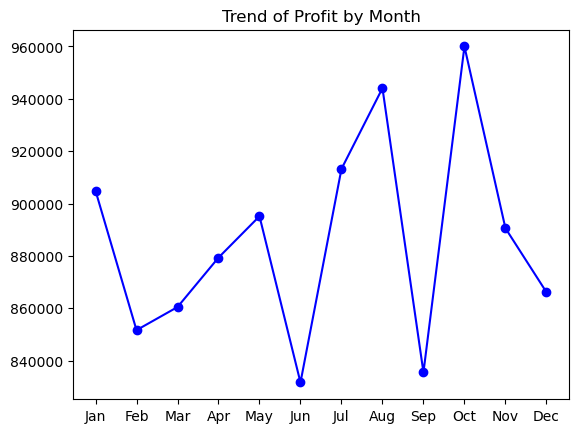

In [139]:
plt.plot(profit_by_month.index, profit_by_month.values, color = 'blue', marker = 'o')
plt.title("Trend of Profit by Month")
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(list(range(1,13)), month_names);

October is the most profitable month, followed closely by August and July. 
Profit dips slightly in June and September but remains relatively stable 
throughout the year, showing no extreme seasonal pattern.

#### **What Product line should Biker Nation have in stock?**

In [71]:
purchase_by_line = new_bikes['product_line'].value_counts()
purchase_by_line

product_line
Standard    13795
Road         3859
Touring      1204
Mountain      415
Name: count, dtype: int64

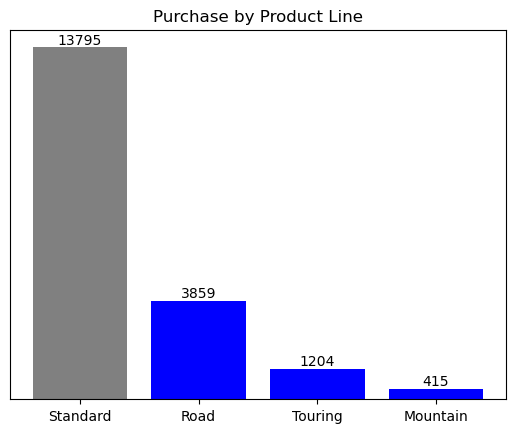

In [82]:
pb_bars = plt.bar(purchase_by_line.index, purchase_by_line.values, color= ['grey', 'blue', 'blue', 'blue'])
plt.title("Purchase by Product Line")
plt.bar_label(pb_bars, purchase_by_line.values.round(2))
plt.yticks([]);

Standard is the most purchased product_line with the highest transaction count, 
followed by Road. Mountain records the least purchases among all product lines.

In [88]:
profit_by_line = new_bikes.groupby('product_line')['profit'].sum().sort_values(ascending = False)
profit_by_line

product_line
Standard   7915300.46
Road       1363069.60
Touring    1314183.77
Mountain     40095.03
Name: profit, dtype: float64

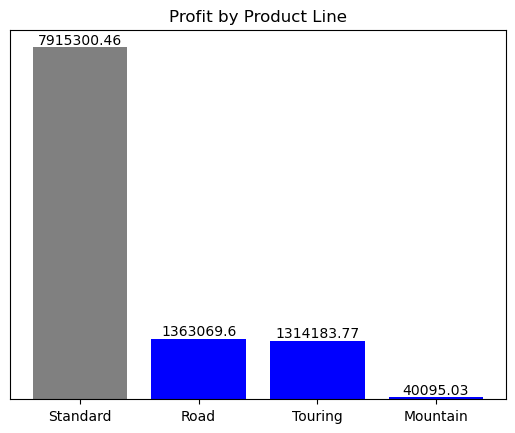

In [89]:
pb_bars = plt.bar(profit_by_line.index, profit_by_line.values, color= ['grey', 'blue', 'blue', 'blue'])
plt.title("Profit by Product Line")
plt.bar_label(pb_bars, profit_by_line.values.round(2))
plt.yticks([]);

Standard also leads in total profit across all product_line categories, 
confirming it is the most important line for Biker Nation to keep well stocked. 
Road comes in second while Mountain generates the least profit.

#### **what sales channel generates the most profit? How great is the difference?**

In [92]:
new_bikes['sales_channel'].value_counts()

sales_channel
Online      9642
In-Store    9631
Name: count, dtype: int64

In [97]:
new_bikes.groupby('sales_channel')['profit'].sum()

sales_channel
In-Store   5344968.90
Online     5287679.96
Name: profit, dtype: float64

The difference is less than 1%, meaning both sales_channel 
options perform almost equally. Biker Nation does not rely heavily on one 
channel over the other.

#### **Which Product size is Most Profitable?**

In [103]:
perc_psize_dist = new_bikes['product_size'].value_counts(normalize=True)
perc_psize_dist

product_size
Medium   0.66
Large    0.20
Small    0.14
Name: proportion, dtype: float64

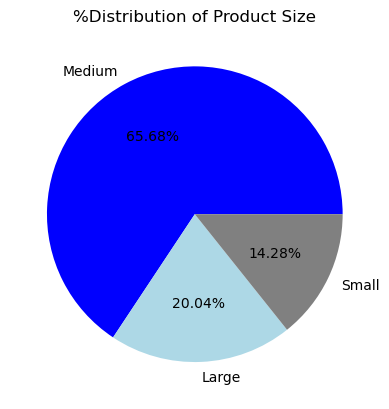

In [109]:
plt.pie(perc_psize_dist, labels=perc_psize_dist.index, autopct= '%1.2f%%', colors=['blue', 'lightblue', 'grey'])
plt.title("%Distribution of Product Size");

Medium product_size accounts for the largest share of sales at over 50%, 
suggesting most customers prefer a mid-sized bike. Large comes in second 
while Small makes up the smallest portion of purchases.

#### **Which Product Class is Most Profitable?**

In [161]:
profit_by_class = new_bikes.groupby('product_class')['profit'].sum().sort_values(ascending=False)
profit_by_class = profit_by_class[profit_by_class.index != 'Unknown']
profit_by_class

product_class
Medium   8383829.64
Low      1170839.24
High     1077979.98
Name: profit, dtype: float64

Medium product_class generates the most profit at $8.3M,  $1.2M for low and High at $1.1M. This tells us Medium class bikes are the sweet 
spot for Biker Nation, selling in high volumes at a profitable margin.

#### **Is There a Quarterly Trend in Profit?**

In [165]:
new_bikes['quarter'] = pd.to_datetime(new_bikes['transaction_date']).dt.quarter
profit_by_quarter = new_bikes.groupby('quarter')['profit'].sum()
profit_by_quarter

quarter
1   2616995.57
2   2606145.96
3   2692793.38
4   2716713.95
Name: profit, dtype: float64

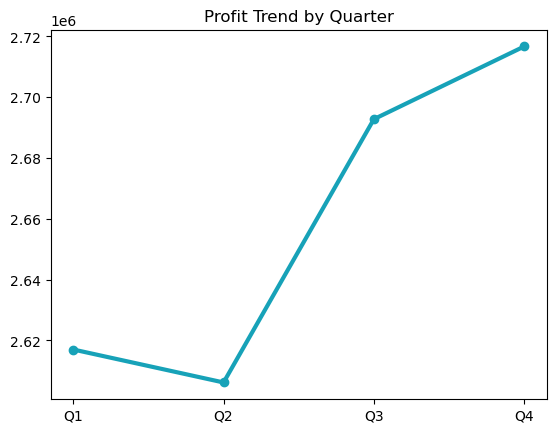

In [163]:
new_bikes['quarter'] = pd.to_datetime(new_bikes['transaction_date']).dt.quarter
profit_by_quarter = new_bikes.groupby('quarter')['profit'].sum()

quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']
plt.plot(quarter_labels, profit_by_quarter.values, color=LINE_COLOR, marker='o', linewidth=3)
plt.title("Profit Trend by Quarter");

Q4 is the most profitable quarter, driven by strong performance in October 
which is the single most profitable month of the year. Q2 is the weakest 
quarter, with June recording the lowest profit across all 12 months. Overall 
profit remains relatively stable across quarters with no dramatic seasonal drop.

#### **Dashboard**

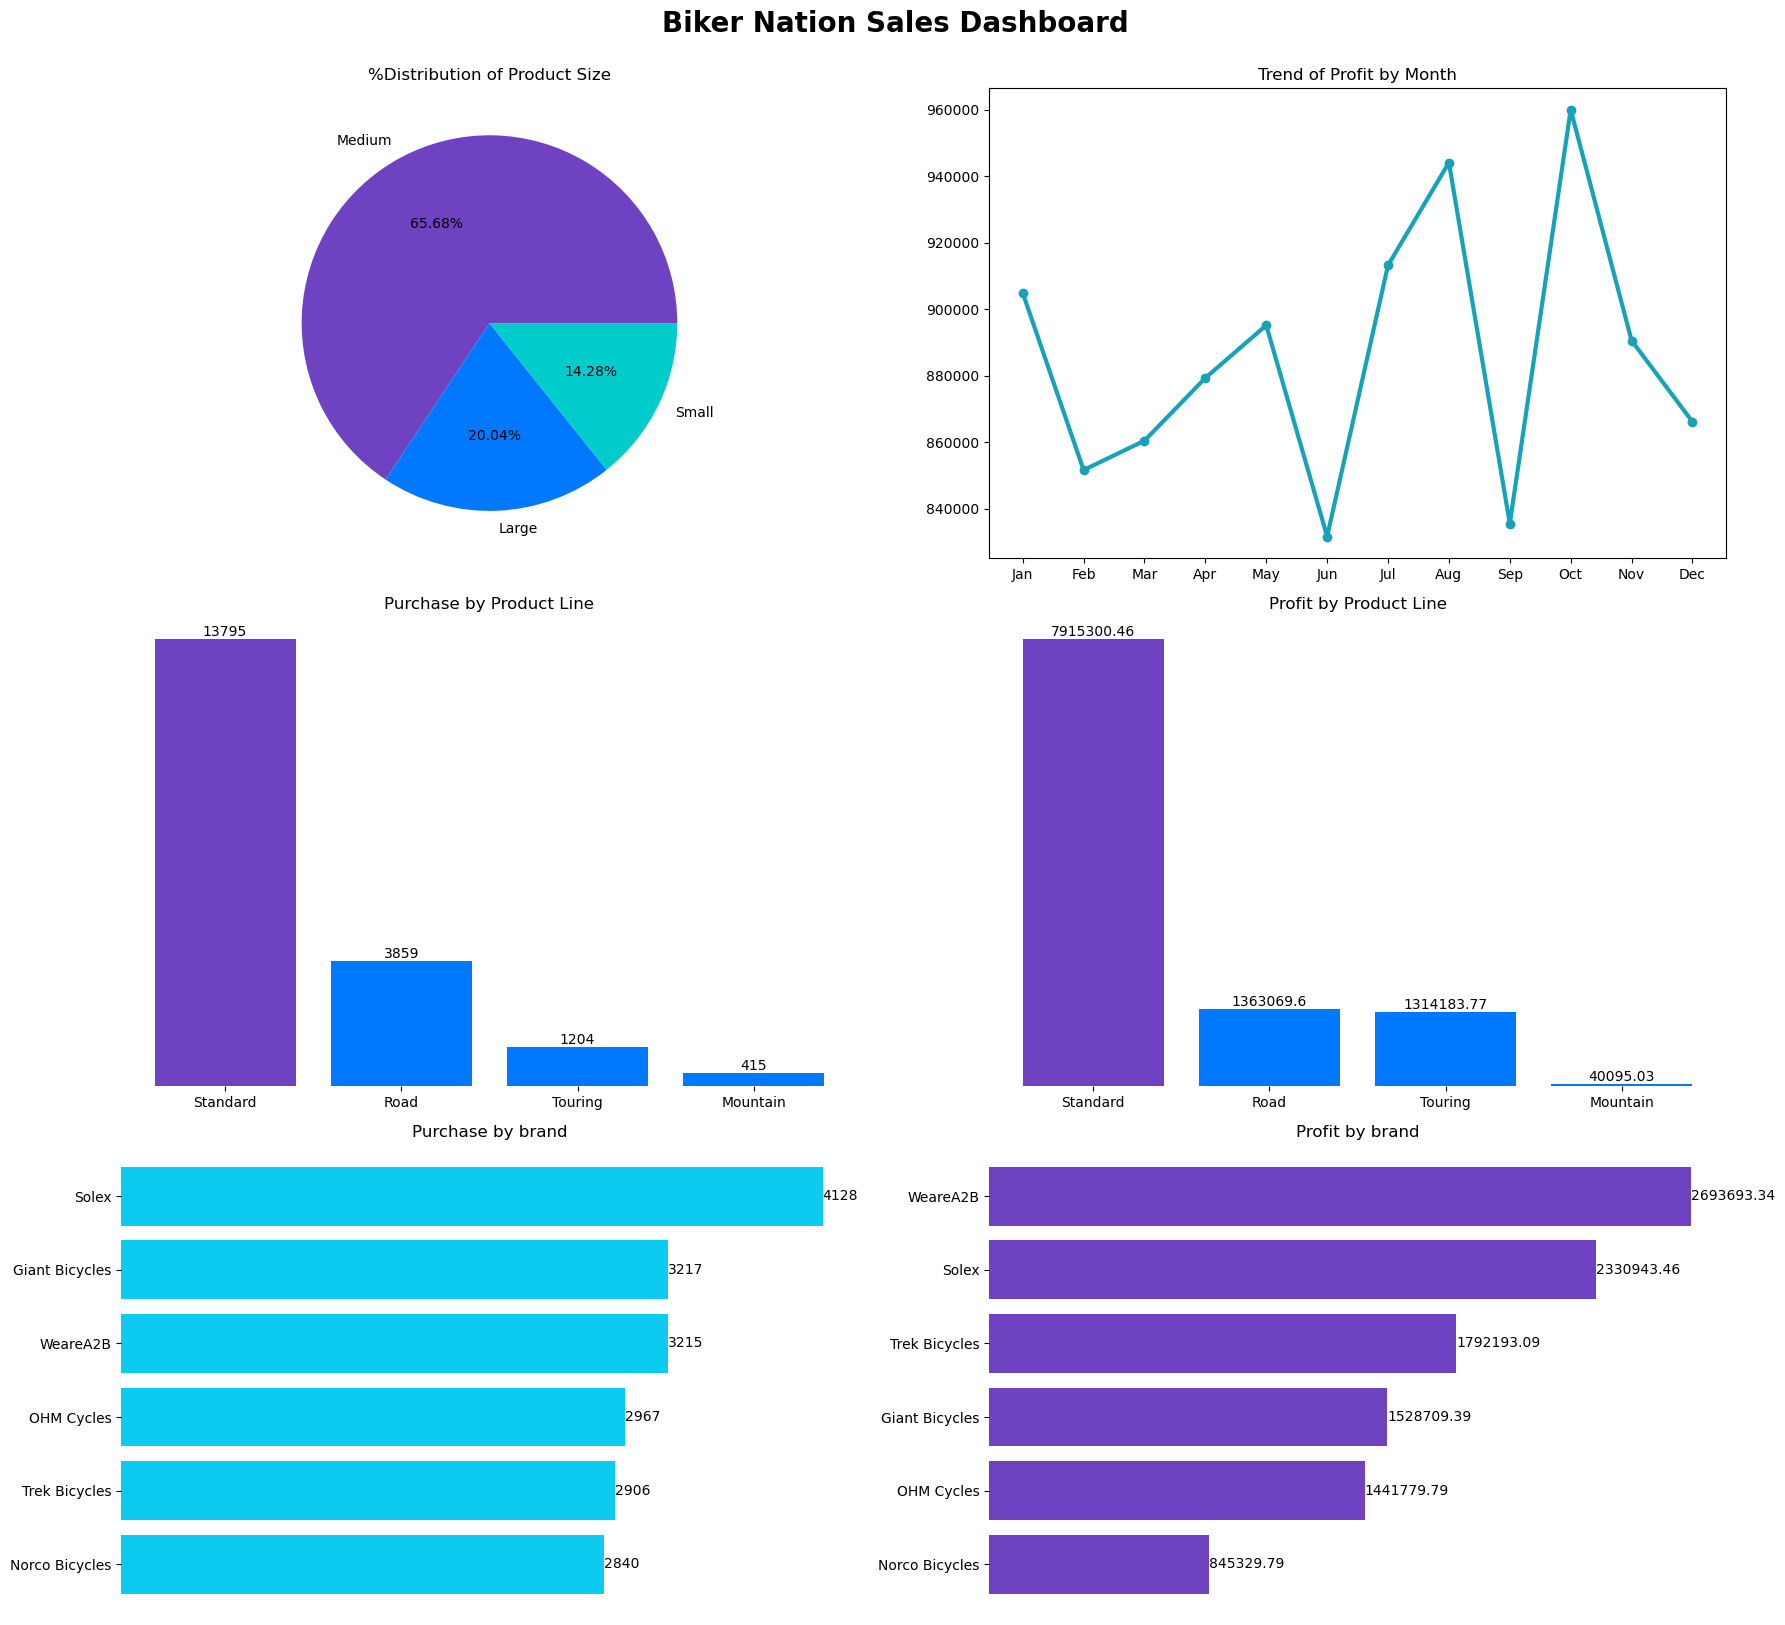

In [156]:
#fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(18,18))
#fig.suptitle("Biker Nation's Sales Dashboard", fontsize=18, color='blue')

PRIMARY = '#FFFFFF'
ACCENT = '#6F42C1'
BAR_COLOR = '#0078FF'
PIE_COLORS = ['#6F42C1', '#0078FF', '#00CCCC']
LINE_COLOR = '#17A2B8'
EXTRA_COLOR = '#0DCAF0'
TEXT_COLOR = 'black'

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(18,18))
fig.patch.set_facecolor(PRIMARY)
fig.suptitle("Biker Nation Sales Dashboard", fontsize=20, color=TEXT_COLOR, fontweight='bold')

for row in ax:
    for a in row:
        a.set_facecolor(PRIMARY)
        a.title.set_color(TEXT_COLOR)
        a.tick_params(colors=TEXT_COLOR)
        
        

#%Distribution of product size
ax[0,0].pie(perc_psize_dist, labels=perc_psize_dist.index, autopct= '%1.2f%%', colors= PIE_COLORS)
ax[0,0].set_title("%Distribution of Product Size");

#Profit by Product Line
pb_bars = ax[1,1].bar(profit_by_line.index, profit_by_line.values, color=[ACCENT, BAR_COLOR, BAR_COLOR, BAR_COLOR])
ax[1,1].set_title("Profit by Product Line")
ax[1,1].bar_label(pb_bars, profit_by_line.values.round(2))
ax[1,1].set_yticks([]);

#Purchase by Product Line
pb_bars = ax[1,0].bar(purchase_by_line.index, purchase_by_line.values, color=[ACCENT, BAR_COLOR, BAR_COLOR, BAR_COLOR])
ax[1,0].set_title("Purchase by Product Line")
ax[1,0].bar_label(pb_bars, purchase_by_line.values.round(2))
ax[1,0].set_yticks([]);

#Purchase by brand
pb_bars = ax[2,0].barh(purchase_by_brand.index, purchase_by_brand.values, color = EXTRA_COLOR)
ax[2,0].set_title("Purchase by brand")
ax[2,0].set_xticks([])
ax[2,0].bar_label(pb_bars, purchase_by_brand.values);

#Profit by brand
pb_bars = ax[2,1].barh(profit_by_brand.index, profit_by_brand.values, color = ACCENT)
ax[2,1].set_title("Profit by brand")
ax[2,1].bar_label(pb_bars, profit_by_brand.values.round(2))
ax[2,1].set_xticks([]);

ax[0,1].plot(profit_by_month.index, profit_by_month.values, color = LINE_COLOR, marker = 'o', linewidth=3)
ax[0,1].set_title("Trend of Profit by Month")
ax[0,1].set_xticks(list(range(1,13)))
ax[0,1].set_xticklabels(month_names);

for spine in ax[1,1].spines.values():
    spine.set_visible(False)

for spine in ax[2,0].spines.values():
   spine.set_visible(False)

for spine in ax[2,1].spines.values():
    spine.set_visible(False)

for spine in ax[1,0].spines.values():
    spine.set_visible(False)
    
plt.tight_layout(rect=[0, 0.08, 1, 0.98])

plt.savefig("Sales dashboard.png", dpi=300, bbox_inches='tight')
plt.show()